In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("default")
# Load dataset
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Examine Dataset Structure

In [4]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (17379, 17)


In [5]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# Statistical summary
df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


### Identifing Numerical and Categorical Variables

In [7]:
# Numerical variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical variables
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
Index(['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Categorical Variables:
Index(['dteday'], dtype='object')


### Missing Values

In [8]:
# Missing values
missing_values = df.isnull().sum()

missing_values

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### Examining Extreme Rental Counts

In [10]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

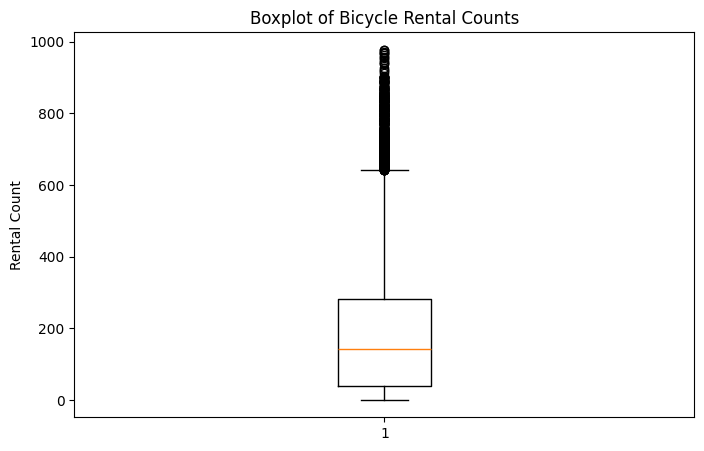

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df['cnt'])

plt.title("Boxplot of Bicycle Rental Counts")

plt.ylabel("Rental Count")

plt.show()

#### Target Variable Inspection

The target variable (`cnt`), representing the total number of bike rentals, was analyzed using descriptive statistics. The dataset contains 17,379 observations with an average demand of 189 rentals and a standard deviation of 181, indicating high variability in rental patterns. The median value (142) is lower than the mean, suggesting a right-skewed distribution caused by periods of high demand. Rental counts range from 1 to 977, showing significant fluctuations in bike usage across different time periods.

### Assessing Weather Variables

In [12]:
weather_cols = ['temp','atemp','hum','windspeed']

df[weather_cols].describe()

,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098
std,0.192556,0.171850,0.192930,0.122340
min,0.020000,0.000000,0.000000,0.000000
25%,0.340000,0.333300,0.480000,0.104500
50%,0.500000,0.484800,0.630000,0.194000
75%,0.660000,0.621200,0.780000,0.253700
max,1.000000,1.000000,1.000000,0.850700


The weather variables contained 17,379 observations with no missing values. All variables were normalized between 0 and 1, as expected from the dataset. Temperature, humidity, and wind speed values were within plausible ranges, with no invalid or unrealistic values detected.

In [13]:
for col in weather_cols:
    print(col)
    print(df[col].min(), df[col].max())
    print()

temp
0.02 1.0

atemp
0.0 1.0

hum
0.0 1.0

windspeed
0.0 0.8507



The weather variables were examined for possible invalid values. Temperature, apparent temperature, humidity, and wind speed were all within the expected normalized range of 0 to 1. No unrealistic values such as negative humidity or wind speed were detected, indicating that the weather variables are suitable for demand forecasting.

### Assess Calendar Variables

In [16]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['dteday'].head()

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: dteday, dtype: datetime64[ns]

In [17]:
calendar_cols = [
    'season',
    'yr',
    'mnth',
    'holiday',
    'weekday',
    'workingday',
    'weathersit'
]

for col in calendar_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


season
season
1    4242
2    4409
3    4496
4    4232
Name: count, dtype: int64

yr
yr
0    8645
1    8734
Name: count, dtype: int64

mnth
mnth
1     1429
2     1341
3     1473
4     1437
5     1488
6     1440
7     1488
8     1475
9     1437
10    1451
11    1437
12    1483
Name: count, dtype: int64

holiday
holiday
0    16879
1      500
Name: count, dtype: int64

weekday
weekday
0    2502
1    2479
2    2453
3    2475
4    2471
5    2487
6    2512
Name: count, dtype: int64

workingday
workingday
0     5514
1    11865
Name: count, dtype: int64

weathersit
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


Calendar variables were inspected to confirm that category values were valid. The dataset contained four seasons, 12 months, seven weekdays, and binary indicators for holiday and working day. Weather situation categories ranged from 1 to 4, with most observations recorded under normal weather conditions. No invalid category values were detected.

### Rental Demand by Hour

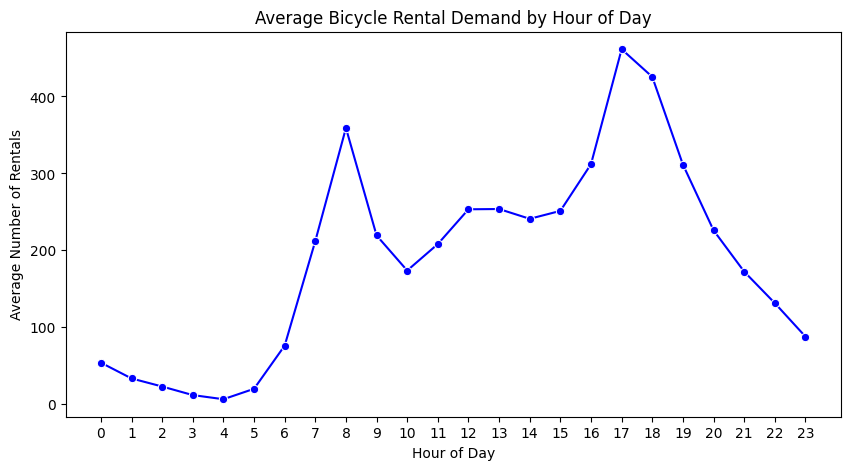

In [20]:
hourly_demand = df.groupby('hr')['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_demand,
    x='hr',
    y='cnt',
    marker='o',
    color='blue'
)

plt.title("Average Bicycle Rental Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Rentals")
plt.xticks(range(0,24))
plt.show()

#### insight
Rental demand shows strong hourly patterns, with noticeable peaks during morning and evening commuting periods. Demand is considerably lower during overnight hours, indicating that time of day is an important predictor of bicycle usage.

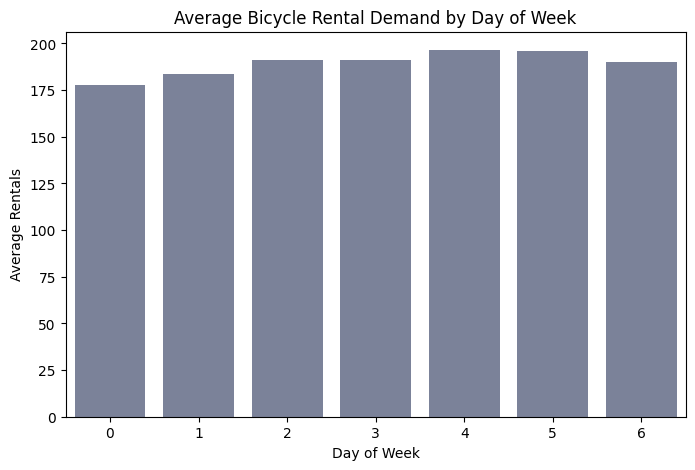

In [23]:
weekday_demand = df.groupby('weekday')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=weekday_demand,
    x='weekday',
    y='cnt',
    color='#767F9E'
)

plt.title("Average Bicycle Rental Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Rentals")

plt.show()

#### insight
Average bicycle rental demand remains relatively stable across the week, ranging between 177 and 196 rentals. The highest demand occurs on Thursday and Friday, while Sunday records the lowest demand. This indicates that day of the week has a moderate influence on rental behavior compared to other factors such as hour, weather, and season.

### Rental Demand by Month

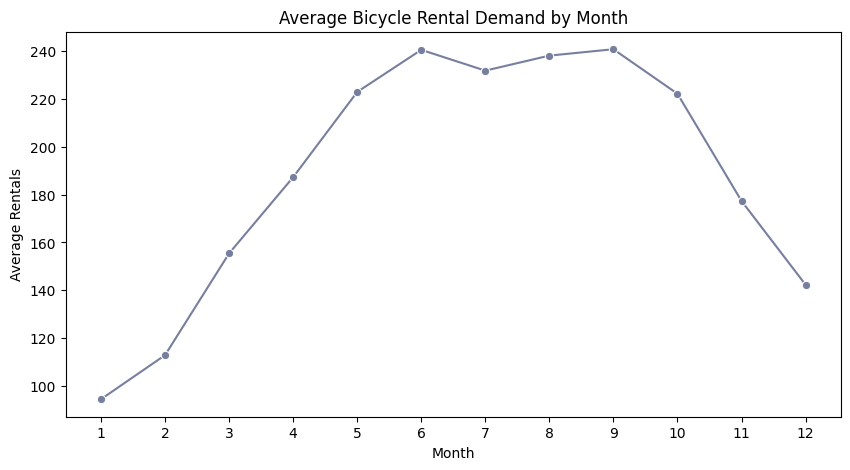

In [24]:
monthly_demand = df.groupby('mnth')['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_demand,
    x='mnth',
    y='cnt',
    marker='o',
     color='#767F9E'
)

plt.title("Average Bicycle Rental Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")

plt.xticks(range(1,13))

plt.show()

#### Demand by Month

Monthly demand analysis shows strong seasonal variation in bicycle rentals. Demand is lowest in January and February but increases steadily, reaching peak levels between June and September. This indicates that seasonality has a significant influence on rental demand and that the month feature is useful for prediction.

### Rental Demand by Season

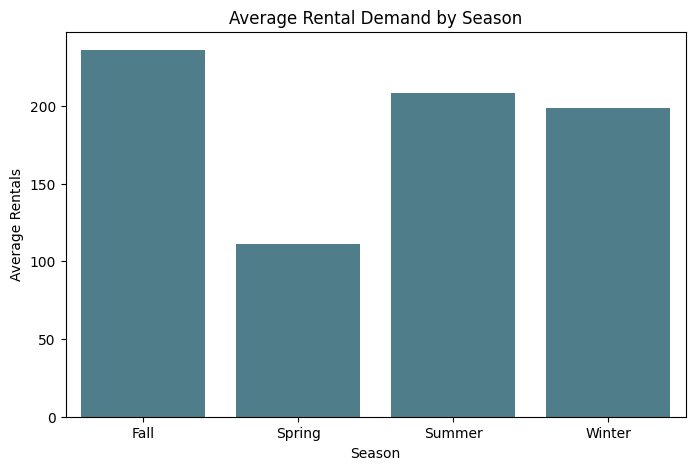

In [25]:
season_map = {
    1:"Spring",
    2:"Summer",
    3:"Fall",
    4:"Winter"
}

df['season_name'] = df['season'].map(season_map)


season_demand = df.groupby(
    'season_name'
)['cnt'].mean().reset_index()


plt.figure(figsize=(8,5))

sns.barplot(
    data=season_demand,
    x='season_name',
    y='cnt',
    color='#458393'
)

plt.title("Average Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.show()

#### Demand by Season

Seasonal analysis shows variations in bicycle rental demand. Fall records the highest average demand (236.02 rentals), while Spring has the lowest demand (111.11 rentals). This indicates that seasonality significantly influences rental behavior and should be considered during model development.

### Weather Situation Impact

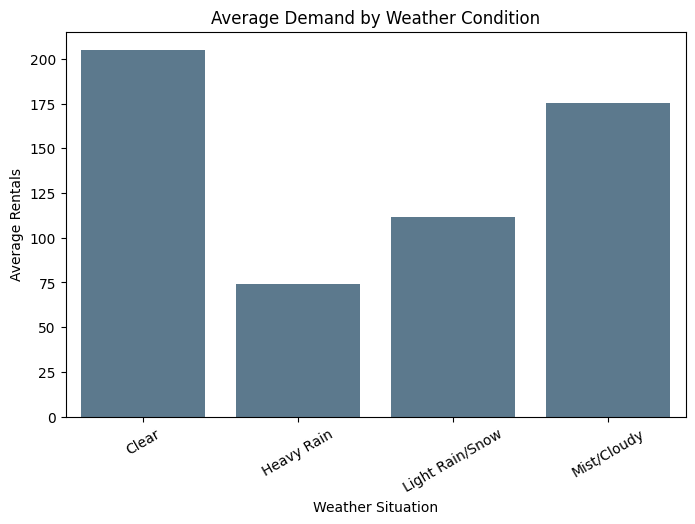

In [26]:
weather_map = {
    1:"Clear",
    2:"Mist/Cloudy",
    3:"Light Rain/Snow",
    4:"Heavy Rain"
}
df['weather_name'] = df['weathersit'].map(weather_map)
weather_demand = df.groupby(
    'weather_name'
)['cnt'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=weather_demand,
    x='weather_name',
    y='cnt',
    color='#547A95'
)
plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")

plt.xticks(rotation=30)
plt.show()

#### Demand by Weather Condition

Weather analysis shows that bicycle rental demand decreases as weather conditions worsen. Clear weather has the highest average demand (204.87 rentals), while heavy rain has the lowest (74.33 rentals). This indicates that weather conditions significantly influence customer rental behavior and should be included as an important predictive feature.

### Temperature vs Rental Demand

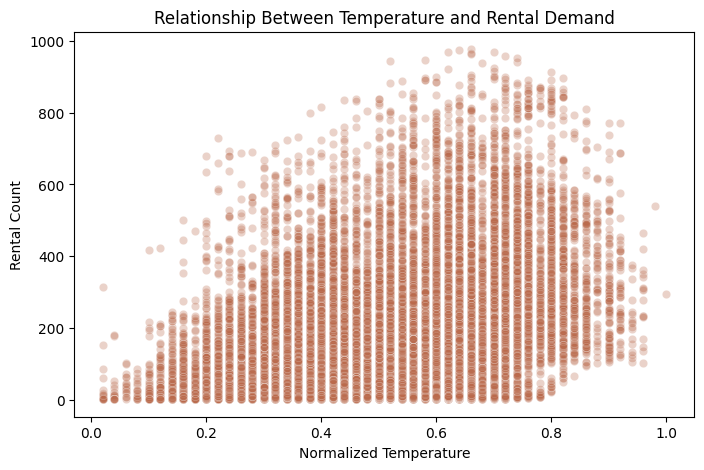

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='temp',
    y='cnt',
    alpha=0.3,
    color='#BA6A4C'
)

plt.title("Relationship Between Temperature and Rental Demand")
plt.xlabel("Normalized Temperature")
plt.ylabel("Rental Count")

plt.show()

#### Temperature and Rental Demand

Temperature shows a positive relationship with bicycle rental demand. Rental counts generally increase as temperature rises, with the highest demand occurring at warmer temperatures. This indicates that temperature is an important predictor of rental behavior, although other factors such as weather, season, and time also influence demand.

### Humidity vs Rental Demand

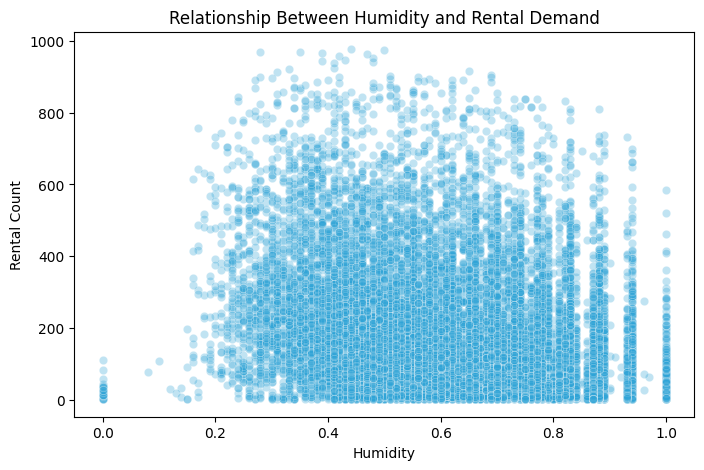

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='hum',
    y='cnt',
    alpha=0.3,
    color='#2FA4D7'
    
)

plt.title("Relationship Between Humidity and Rental Demand")
plt.xlabel("Humidity")
plt.ylabel("Rental Count")

plt.show()

#### Humidity and Rental Demand

The scatter plot shows the relationship between humidity and bicycle rental demand. The pattern suggests that higher humidity levels generally reduce rental demand, as uncomfortable weather conditions may discourage bicycle usage. However, the relationship appears weaker compared to factors such as temperature and time of day, indicating that humidity alone may not strongly predict rental demand.

### Wind Speed vs Rental Demand

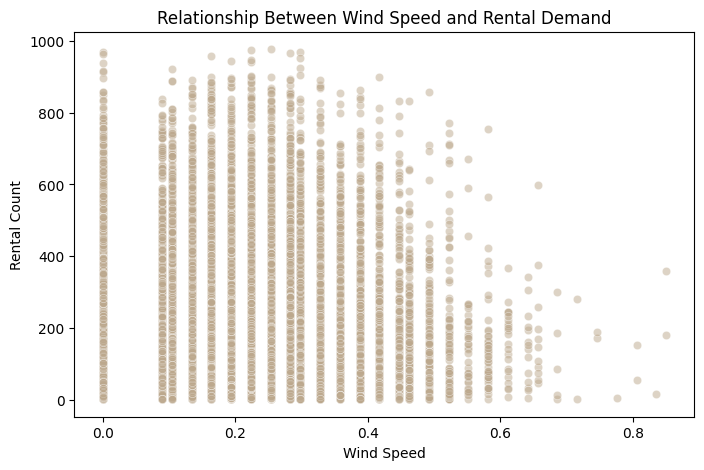

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='windspeed',
    y='cnt',
    alpha=0.5,
     color='#BCA88D'
    
)

plt.title("Relationship Between Wind Speed and Rental Demand")
plt.xlabel("Wind Speed")
plt.ylabel("Rental Count")

plt.show()

#### Wind Speed and Rental Demand

Wind speed shows a weak relationship with bicycle rental demand. Demand remains relatively stable at low to moderate wind speeds but decreases under extreme wind conditions. This suggests that wind speed has some influence on rental behavior but is less important compared to factors such as temperature, weather, and time-based features.

### Working Day Status

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


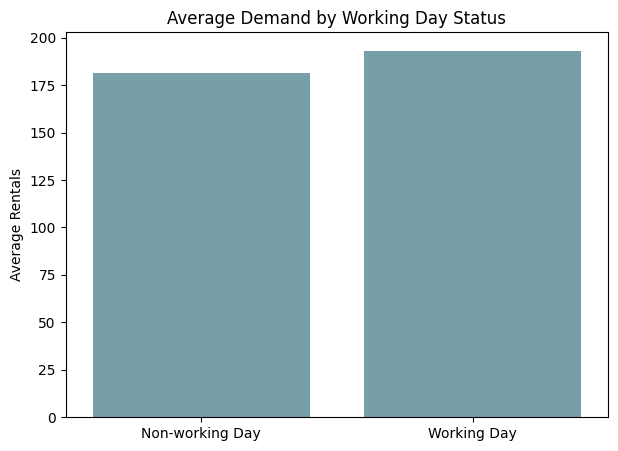

In [30]:
working_demand = df.groupby(
    'workingday'
)['cnt'].mean().reset_index()


working_demand['workingday'] = working_demand['workingday'].map({
    0:"Non-working Day",
    1:"Working Day"
})


plt.figure(figsize=(7,5))

sns.barplot(
    data=working_demand,
    x='workingday',
    y='cnt',
    color='#6FA4AF'
)

plt.title("Average Demand by Working Day Status")
plt.xlabel("")
plt.ylabel("Average Rentals")

plt.show()

#### Demand by Working Day Status

Working days show slightly higher average bicycle rental demand (193.21 rentals) compared to non-working days (181.41 rentals). This suggests that commuting patterns contribute to rental usage, although other factors such as time, weather, and season may have a greater influence on demand.

### Holiday Status

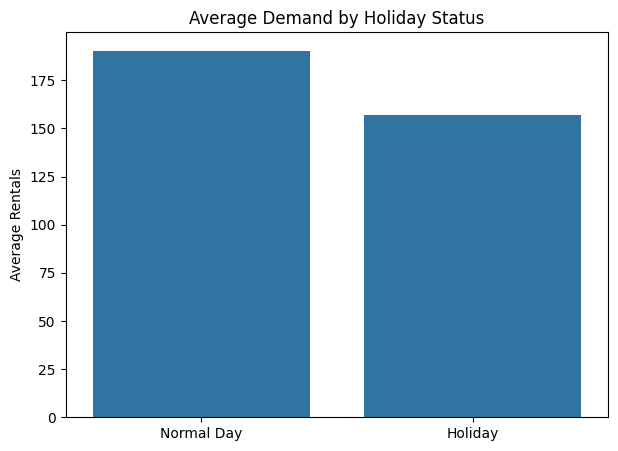

In [31]:
holiday_demand = df.groupby(
    'holiday'
)['cnt'].mean().reset_index()


holiday_demand['holiday'] = holiday_demand['holiday'].map({
    0:"Normal Day",
    1:"Holiday"
})


plt.figure(figsize=(7,5))

sns.barplot(
    data=holiday_demand,
    x='holiday',
    y='cnt'
)

plt.title("Average Demand by Holiday Status")
plt.xlabel("")
plt.ylabel("Average Rentals")

plt.show()

#### Demand by Holiday Status

Normal days show higher average bicycle rental demand (190.43 rentals) compared to holidays (156.87 rentals). This suggests that commuting activities contribute significantly to rental usage, while holidays may experience reduced demand due to fewer routine trips.

## Feature Engineering

In [50]:
df_model = df.copy()

### Date-based Features

In [51]:
# Ensure datetime format
df_model['dteday'] = pd.to_datetime(df_model['dteday'])

# Extract date features
df_model['day'] = df_model['dteday'].dt.day
df_model['weekofyear'] = df_model['dteday'].dt.isocalendar().week
df_model['quarter'] = df_model['dteday'].dt.quarter

### Weekend Indicator Feature

In [52]:
df_model['is_weekend'] = df_model['weekday'].isin([0,6]).astype(int)

### Rush Hour Feature

In [55]:
df_model['rush_hour'] = df_model['hr'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0
)

### Temperature-Humidity Interaction

In [56]:
df_model['temperature_celsius'] = df_model['temp'] * 41

df_model['feels_like_celsius'] = df_model['atemp'] * 50

### Temperature Comfort Index

In [57]:
df_model['temp_humidity_index'] = (
    df_model['temp'] * (1 - df_model['hum'])
)

### Weather Severity Score

In [58]:
weather_score = {
    1:0,   # Clear
    2:1,   # Mist/cloudy
    3:2,   # Rain/snow
    4:3    # Heavy weather
}

df_model['weather_severity'] = (
    df_model['weathersit']
    .map(weather_score)
)

### Hour Cyclic Encoding

In [59]:

df_model['hour_sin'] = np.sin(
    2*np.pi*df_model['hr']/24
)

df_model['hour_cos'] = np.cos(
    2*np.pi*df_model['hr']/24
)

### Month Cyclic Encoding

In [60]:
df_model['month_sin'] = np.sin(
    2*np.pi*df_model['mnth']/12
)

df_model['month_cos'] = np.cos(
    2*np.pi*df_model['mnth']/12
)

### Lag Features (Important for Forecasting)

In [61]:
df_model = df_model.sort_values(
    ['dteday','hr']
)

#### Previous hour demand

In [62]:
df_model['lag_1_hour'] = (
    df_model['cnt'].shift(1)
)

#### Previous day same hour demand

In [63]:
df_model['lag_24_hour'] = (
    df_model['cnt'].shift(24)
)

### Previous week same hour demand

In [64]:
df_model['lag_168_hour'] = (
    df_model['cnt'].shift(168)
)

### Rolling Average Demand

In [65]:
df_model['rolling_24_hour_mean'] = (
    df_model['cnt']
    .shift(1)
    .rolling(window=24)
    .mean()
)

### Remove Leakage Variables

In [66]:
df_model = df_model.drop(
    columns=[
        'casual',
        'registered'
    ]
)

### Handle Missing Values Created by Lag Features

In [67]:
df_model.isnull().sum()

instant                   0
dteday                    0
season                    0
yr                        0
mnth                      0
hr                        0
holiday                   0
weekday                   0
workingday                0
weathersit                0
temp                      0
atemp                     0
hum                       0
windspeed                 0
cnt                       0
season_name               0
weather_name              0
day                       0
weekofyear                0
rush_hour                 0
temp_humidity             0
wind_effect               0
weekend                   0
quarter                   0
is_weekend                0
temperature_celsius       0
feels_like_celsius        0
temp_humidity_index       0
weather_severity          0
hour_sin                  0
hour_cos                  0
month_sin                 0
month_cos                 0
lag_1_hour                1
lag_24_hour              24
lag_168_hour        

In [68]:
df_model = df_model.dropna()

### Select Features and Target

In [69]:
features = [
    'hr',
    'weekday',
    'mnth',
    'season',
    'holiday',
    'workingday',
    'weathersit',
    'temp',
    'hum',
    'windspeed',
    'is_weekend',
    'rush_hour',
    'weather_severity',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'lag_1_hour',
    'lag_24_hour',
    'lag_168_hour',
    'rolling_24_hour_mean'
]


X = df_model[features]

y = df_model['cnt']

### Feature Engineering Summary

Features were developed from time, calendar, and weather variables to improve demand prediction. Time-based features such as hour, month, and weekday capture demand patterns, while rush-hour and weekend indicators represent customer behaviour. Weather interaction features were created to capture combined effects of temperature, humidity, and wind conditions on bicycle rental demand.

## Prepare Data Using Time-Based Split

In [70]:
# Sort data chronologically
df_model = df_model.sort_values(
    ['dteday', 'hr']
).reset_index(drop=True)

### Separate Features and Target

In [71]:
y = df_model['cnt']

#### Predictor variables:

In [72]:
X = df_model.drop(
    columns=[
        'cnt',
        'dteday',
        'season_name',
        'weather_name'
    ],
    errors='ignore'
)

### Chronological Train-Test Split

In [73]:
split_index = int(len(df_model) * 0.8)


X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]


y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print(X_train.shape)
print(X_test.shape)

(13768, 33)
(3443, 33)


Since bicycle rental demand follows temporal patterns, a chronological split was applied instead of random sampling. Random splitting could introduce future information into the training dataset, resulting in optimistic performance estimates. The first 80% of observations were used for model training, while the remaining 20% representing future periods were reserved for testing.

### Feature Scaling

In [74]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

### Model 1: Linear Regression (Baseline)
Linear Regression provides a simple benchmark and measures whether demand can be explained through linear relationships.

In [75]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()


lr_model.fit(
    X_train_scaled,
    y_train
)


lr_predictions = lr_model.predict(
    X_test_scaled
)

### Model 2: Random Forest Regression
Why Random Forest?

Random Forest can capture:

- nonlinear weather effects,
- complex interactions,
- seasonal patterns.

In [76]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(
    X_train,
    y_train
)


rf_predictions = rf_model.predict(
    X_test
)

### Model 3: XGBoost Regression
Why XGBoost?

XGBoost is a gradient boosting algorithm that performs well on structured datasets by combining multiple weak learners to improve prediction accuracy.

In [77]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)


xgb_predictions = xgb_model.predict(
    X_test
)

### Hyperparameter Tuning

In [78]:
from sklearn.model_selection import GridSearchCV


rf_params = {
    'n_estimators':[100,200],
    'max_depth':[10,15,20],
    'min_samples_split':[2,5]
}


grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)


grid_rf.fit(
    X_train,
    y_train
)


print(grid_rf.best_params_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [79]:
xgb_params = {
    'n_estimators':[300,500],
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1]
}


grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)


grid_xgb.fit(
    X_train,
    y_train
)


print(grid_xgb.best_params_)

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}


Three regression models were developed to forecast bicycle rental demand: Linear Regression, Random Forest Regression, and XGBoost Regression. Linear Regression was selected as a baseline model because of its simplicity and interpretability. Random Forest was implemented because it can capture nonlinear relationships between demand and influencing factors such as weather and time variables. XGBoost was selected as an advanced ensemble learning method due to its strong performance on structured datasets and ability to model complex interactions between predictors.

To preserve the forecasting nature of the problem, the dataset was split chronologically rather than randomly. Earlier observations were used for training, while later observations were reserved for testing. This approach prevents future information leakage and provides a realistic evaluation of how the models would perform when predicting future bicycle demand.

## Calculate Evaluation Metrics

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(name, y_true, predictions):
    
    mae = mean_absolute_error(
        y_true,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )
    
    r2 = r2_score(
        y_true,
        predictions
    )
    
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


results = []


results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_predictions
    )
)


results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)


results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions
    )
)


results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,58.478978,86.778214,0.844172
1,Random Forest,32.169624,54.495579,0.938547
2,XGBoost,29.274171,46.435741,0.955380


### Visualize Actual vs Predicted Demand

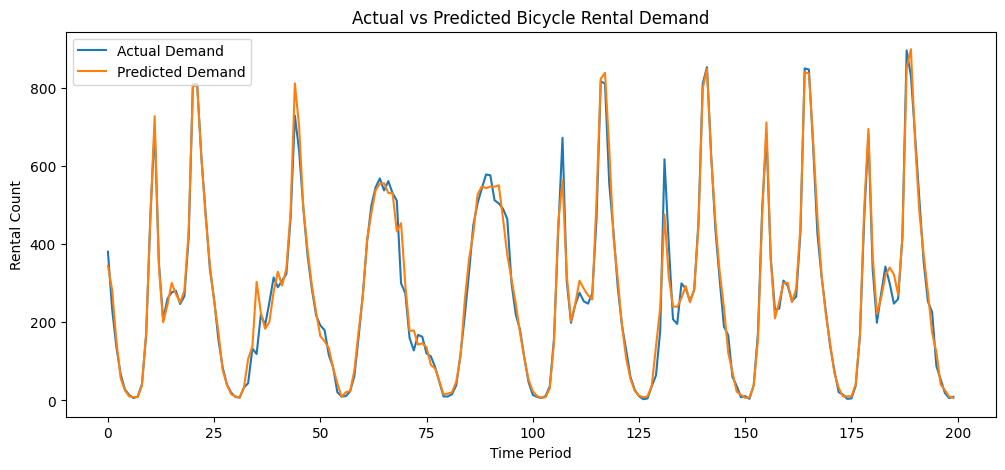

In [81]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:200],
    label="Actual Demand"
)

plt.plot(
    xgb_predictions[:200],
    label="Predicted Demand"
)

plt.title(
    "Actual vs Predicted Bicycle Rental Demand"
)

plt.xlabel("Time Period")
plt.ylabel("Rental Count")

plt.legend()

plt.show()

### Feature Importance Analysis

In [82]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})


importance = importance.sort_values(
    by='Importance',
    ascending=False
)


importance.head(15)

,Feature,Importance
29,lag_1_hour,0.374604
31,lag_168_hour,0.100109
30,lag_24_hour,0.063398
15,rush_hour,0.062711
25,hour_sin,0.057908
7,workingday,0.052354
26,hour_cos,0.045545
18,weekend,0.040167
4,hr,0.038090
24,weather_severity,0.034705


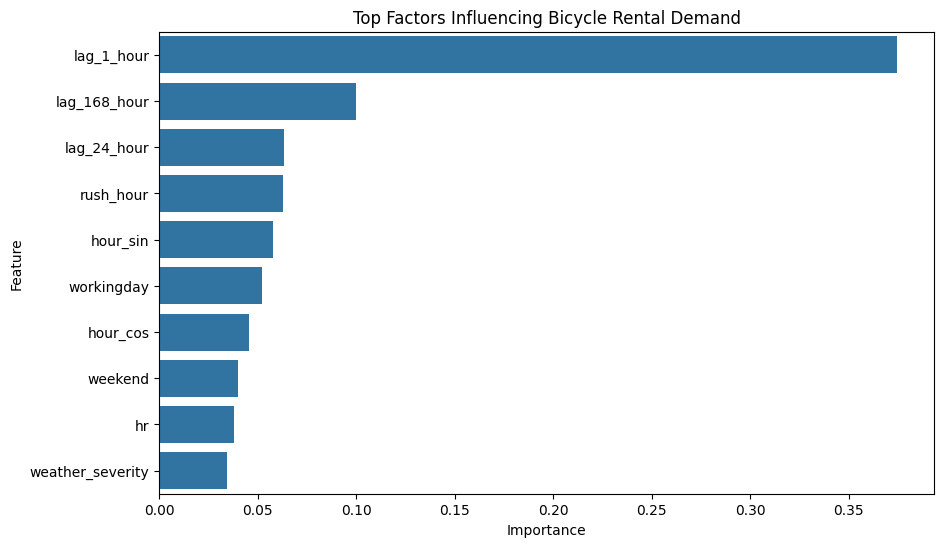

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top Factors Influencing Bicycle Rental Demand"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()